# Import modules

In [29]:
import timm
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import os
import glob
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import torch.nn.functional as F
import wandb
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("wandb_classifier")

check = wandb.login(secret_value_0)

if check:
    print('wandb login succsssful!')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nobonobonobok (nobonobonobok-university-of-cambridge) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb login succsssful!


In [3]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

cuda


# Data loading

In [4]:
#loading data
train_data_dir="/kaggle/input/datasets/kogennobori/oct-original-dataset/combined2_split_rgb_jpeg/train"

test_data_dir="/kaggle/input/datasets/kogennobori/oct-original-dataset/combined2_split_rgb_jpeg/test"
#Reference: https://stackoverflow.com/questions/10439104/reading-bmp-files-in-python

In [5]:
# set image size here
img_size=224

#Reference: https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
train_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
])

tv_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
])
#Reference: https://stackoverflow.com/questions/69199273/torchvision-imagefolder-could-not-find-any-class-folder

train_data=datasets.ImageFolder(train_data_dir, transform=train_transform)
test_data=datasets.ImageFolder(test_data_dir,transform=tv_transform)


train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Model setup

In [6]:
model = timm.create_model('resnet34', pretrained=True, num_classes = 10)
model.to(device)

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

# Training

In [7]:
# set hyperparameters
epochs = 10
lr = 0.01
momentum = 0.9

In [8]:
# set loss function and optimisation method
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

In [9]:
# wandb setting.
# Project that the run is recorded to
project = "classifier"


config = {
    'epochs' : epochs,
    'lr' : lr,
    'momentum' : momentum,
    'dataset_folder': train_data_dir
}

In [10]:
# training loop
with wandb.init(project=project, config=config) as run:
    for epoch in range(epochs):
        print(f"Training epoch {epoch}...")
    
        running_loss =0.0
        #Reference: https://zenn.dev/zzz/articles/970e5df5cf1f65
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
        
            optimizer.zero_grad()
        
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
            running_loss += loss.item()

            loss = round((running_loss / len(train_loader)),4)
            
        print((f'Loss:{loss}'))
        run.log({"loss": loss})
      
    
    print("finished Training!")

    # Save the model
    torch.save(model.state_dict(), 'trained_net.pth')
    
    artifact = wandb.Artifact('classifier', type='model')

    #Specify the path to the model checkpoint file that you want to upload
    artifact.add_file('trained_net.pth') 
    
    run.log_artifact(artifact)

Training epoch 0...
Loss:0.3079
Training epoch 1...
Loss:0.1422
Training epoch 2...
Loss:0.1139
Training epoch 3...


Traceback (most recent call last):
  File "/tmp/ipykernel_58/1751841037.py", line 17, in <cell line: 0>
    running_loss += loss.item()
                    ^^^^^^^^^^^
KeyboardInterrupt


loss,█▂▁
loss,0.1139


KeyboardInterrupt: 

In [12]:
# script for saving the model in case you stopped training loop before it saves a model.

# torch.save(model.state_dict(), 'trained_net.pth')

# #Specify the project name and run ID found in Run path. (username/project_name/run_id)
# run = wandb.init(project='classifier', id='8x7y6a6i', resume='allow')
# artifact = wandb.Artifact('classifier', type='model', description="test: resnet34, original OCT dataset, interrupted during epoch 3, achieved accuracy 95.8%")

# #Specify the path to the model checkpoint file that you want to upload
# artifact.add_file('trained_net.pth') 

# run.log_artifact(artifact)
# run.finish()

loss,0.1139


# Testing

In [6]:
# Loading the model. Not necessary if you already have.
model = timm.create_model('resnet34', pretrained=True, num_classes = 10)
model.to(device)
model.load_state_dict(torch.load("/kaggle/input/models/kogennobori/classifeier/pytorch/default/1/trained_net.pth"))
model.eval() # is this necessary?

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

In [7]:
print(test_data.class_to_idx)

{'AMD': 0, 'CNV': 1, 'CSR': 2, 'DME': 3, 'DRUSEN': 4, 'ERM': 5, 'NORMAL': 6, 'RAO': 7, 'RVO': 8, 'VID': 9}


In [8]:
# https://stackoverflow.com/questions/68047990/pytorch-imagefolder-which-index-does-a-folder-get
classes = ('AMD','CNV', 'CSR', 'DME', 'DRUSEN', 'ERM', 'NORMAL', 'RAO', 'RVO', 'VID' )

## Calculation of accuracy

In [9]:
correct = 0
total = 0

with torch.no_grad():
  for data in test_loader:
    images,labels = data[0].to(device), data[1].to(device)
    outputs=model(images)
    _, predicted = torch.max(outputs,1)
    total+=labels.size(0)
    correct+=(predicted == labels).sum().item()

accuracy = round(100*correct/total,2)

print(f"Accuracy of the model is: {accuracy}%")

Accuracy of the model is: 95.8%


## Visualisation

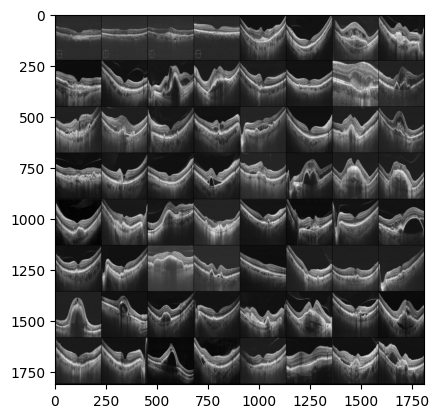

GroundTruth:  AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD  
Predicted:  VID   NORMAL AMD   NORMAL AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   NORMAL AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   NORMAL AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD  


In [10]:
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
# https://stackoverflow.com/questions/59013109/runtimeerror-input-type-torch-floattensor-and-weight-type-torch-cuda-floatte
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(test_loader)
images, labels = next(dataiter)[0].to(device), next(dataiter)[1].to(device)


# print images
imshow(torchvision.utils.make_grid(images).cpu())
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(64)))

outputs = model(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(64)))

## Confusion matrix

In [13]:
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: AMD   is 90.8 %
Accuracy for class: CNV   is 96.9 %
Accuracy for class: CSR   is 36.4 %
Accuracy for class: DME   is 91.2 %
Accuracy for class: DRUSEN is 81.1 %
Accuracy for class: ERM   is 25.0 %
Accuracy for class: NORMAL is 99.3 %
Accuracy for class: RAO   is 0.0 %
Accuracy for class: RVO   is 9.1 %
Accuracy for class: VID   is 95.5 %


In [17]:
true = []
pred = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels.cpu(), predictions.cpu()):
            true.append(label)
            pred.append(prediction)

            
cm = confusion_matrix(true, pred)

# print(cm)



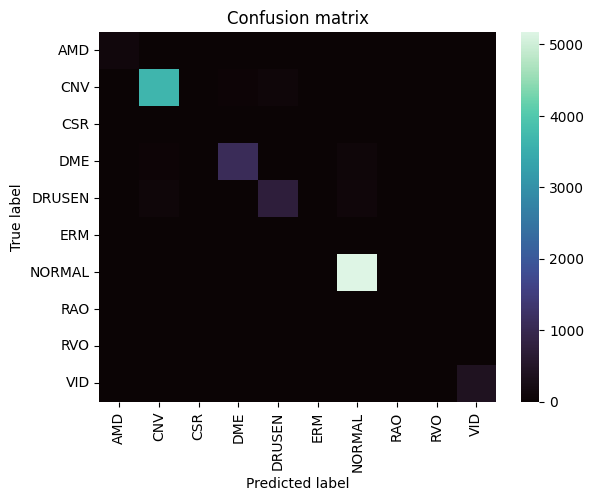

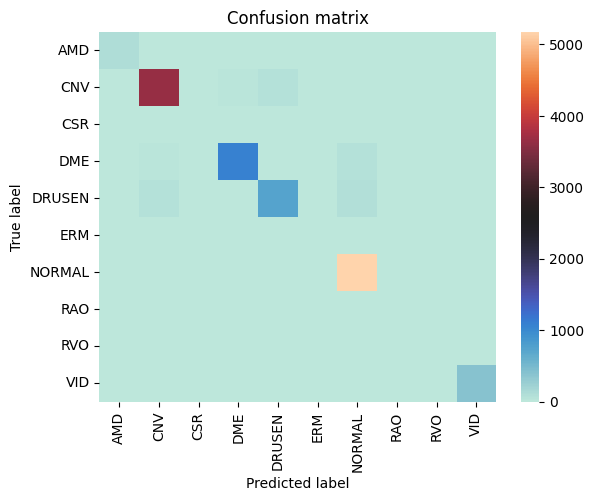

In [35]:
df_cm = pd.DataFrame(cm, columns = classes, index = classes)
# df_cm = pd.DataFrame(cm)

sns.heatmap(df_cm, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix')
plt.show()

# diverging color palette
sns.heatmap(df_cm, cmap='icefire')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix')
plt.show()

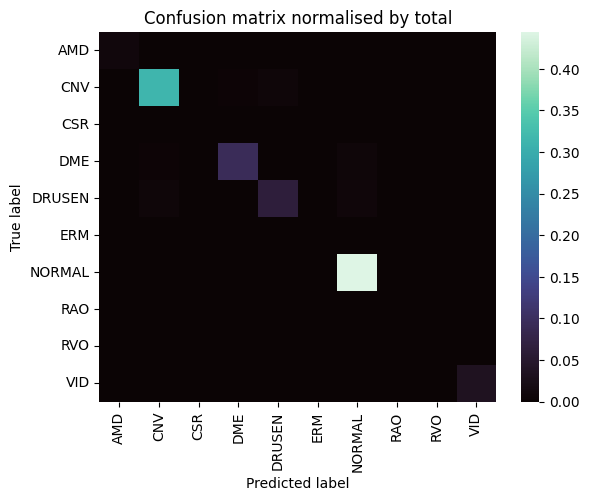

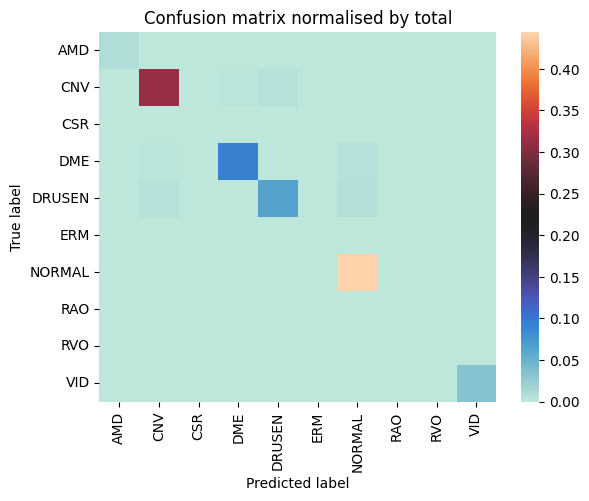

In [46]:
# normalised confusion matrix
total_n = len(true)

df_cm_norm = df_cm/total_n

sns.heatmap(df_cm_norm, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by total')
plt.show()

sns.heatmap(df_cm_norm, cmap='icefire')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by total')
plt.show()

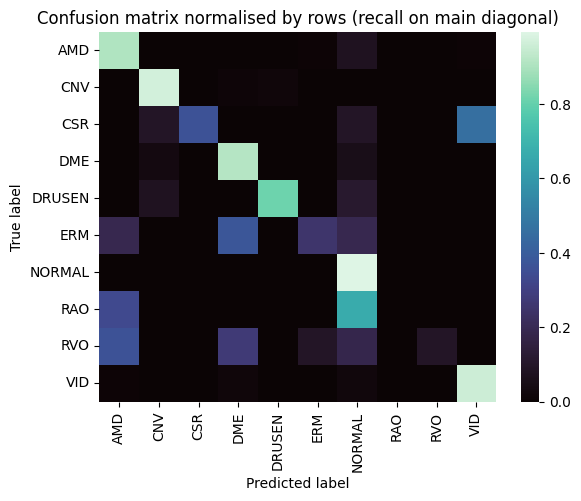

In [48]:
# https://stackoverflow.com/questions/35678874/normalize-rows-of-pandas-data-frame-by-their-sums
sums_row = np.sum(cm, axis=1)
# Source - https://stackoverflow.com/a/35679163
# Posted by Ami Tavory
# Retrieved 2026-08-25, License - CC BY-SA 3.0

df_cm_norm_rows = df_cm.div(sums_row, axis=0)

sns.heatmap(df_cm_norm_rows, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by rows (recall on main diagonal)')
plt.show()

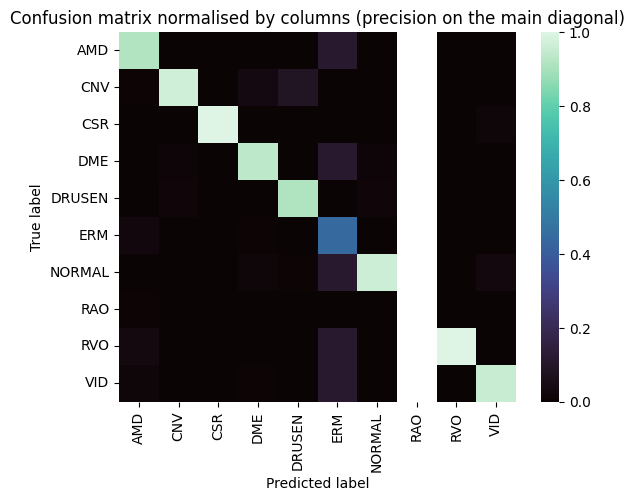

In [49]:
# https://stackoverflow.com/questions/35678874/normalize-rows-of-pandas-data-frame-by-their-sums
sums_row = np.sum(cm, axis=0)


df_cm_norm_rows = df_cm.div(sums_row, axis=1)

sns.heatmap(df_cm_norm_rows, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by columns (precision on the main diagonal)')
plt.show()

In [50]:
# matrix summary
print(classification_report(true, pred, target_names=classes))

              precision    recall  f1-score   support

         AMD       0.91      0.91      0.91       130
         CNV       0.97      0.97      0.97      3756
         CSR       1.00      0.36      0.53        11
         DME       0.94      0.91      0.92      1185
      DRUSEN       0.91      0.81      0.86       901
         ERM       0.44      0.25      0.32        16
      NORMAL       0.96      0.99      0.98      5207
         RAO       0.00      0.00      0.00         3
         RVO       1.00      0.09      0.17        11
         VID       0.95      0.95      0.95       418

    accuracy                           0.96     11638
   macro avg       0.81      0.63      0.66     11638
weighted avg       0.96      0.96      0.96     11638



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
